**[Diamonds](https://www.kaggle.com/shivam2503/diamonds):
Analyze diamonds by their cut, color, clarity, price, and other attributes**

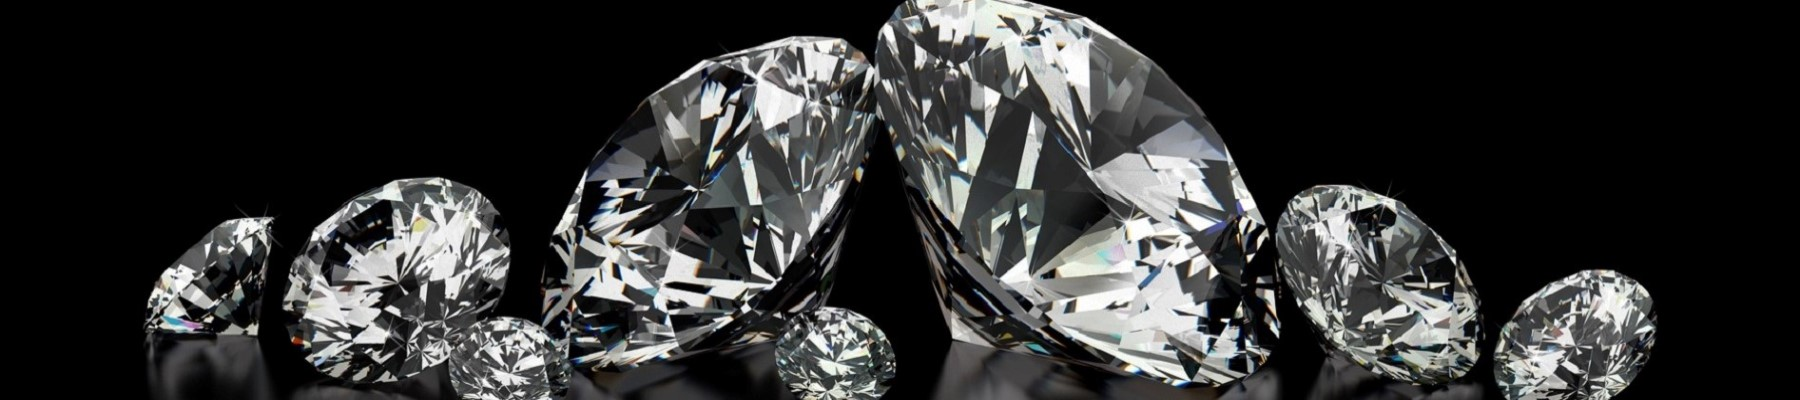

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
%matplotlib inline
np.random.seed(1)
warnings.filterwarnings('ignore', 'Maximum number of iteration reached before convergence.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Liblinear failed to converge, increase the number of iterations.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Warm-start fitting without increasing n_estimators does not fit new trees.*') #Sem isso aqui ele fica falando pra aumentar o max_iter


**Processo de download automático dos dados**

In [ ]:
!gdown --id '1gK5kFGCcLNM7wjI2soy-yQDb0tI-iJFv'

Downloading...
From: https://drive.google.com/uc?id=1gK5kFGCcLNM7wjI2soy-yQDb0tI-iJFv
To: /content/diamante.csv
100% 3.19M/3.19M [00:00<00:00, 103MB/s]


**Tratamento de dados**

carat: Peso em quilates do diamante.

cut: Descreva a qualidade do corte do diamante. Qualidade em ordem crescente Fair, Good, Very Good, Premium, Ideal.

color: Cor do diamante, sendo D o melhor e J o pior.

clarity: Quão óbvias são as inclusões dentro do diamante: (da melhor para a pior, FL = flawless, I3= inclusões de nível 3) FL,IF, VVS1,

depth: depth%: a altura de um diamante, medida do culet até a mesa, dividida por seu diâmetro médio de cintura

table: table%: A largura da mesa do diamante expressa como uma porcentagem de seu diâmetro médio

price: o preço do diamante

x: comprimento mm

y: largura mm

z: profundidade mm 

In [ ]:
df_diamante = pd.read_csv('diamante.csv')

In [ ]:
df_diamante = df_diamante.drop(columns=['Unnamed: 0'])

In [ ]:
df_diamante

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df_diamante.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [ ]:
df_diamante.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [ ]:
df_diamante['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [ ]:
df_diamante['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [ ]:
df_diamante['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [ ]:
df_diamante = pd.get_dummies(df_diamante,columns=['cut'], drop_first=False)

In [ ]:
df_diamante = pd.get_dummies(df_diamante,columns=['color'], drop_first=False)

In [ ]:
df_diamante = pd.get_dummies(df_diamante,columns=['clarity'], drop_first=False)

In [ ]:
df_diamante

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_D,color_E,color_F,color_G,color_H,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_diamante.dtypes

carat            float64
depth            float64
table            float64
price              int64
x                float64
y                float64
z                float64
cut_Fair           uint8
cut_Good           uint8
cut_Ideal          uint8
cut_Premium        uint8
cut_Very Good      uint8
color_D            uint8
color_E            uint8
color_F            uint8
color_G            uint8
color_H            uint8
color_I            uint8
color_J            uint8
clarity_I1         uint8
clarity_IF         uint8
clarity_SI1        uint8
clarity_SI2        uint8
clarity_VS1        uint8
clarity_VS2        uint8
clarity_VVS1       uint8
clarity_VVS2       uint8
dtype: object

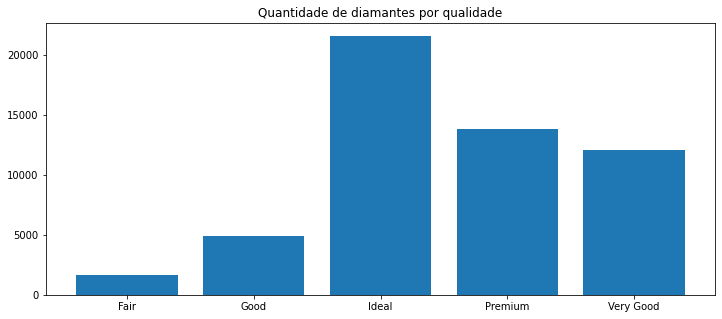

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(['Fair', 'Good', 'Ideal', 'Premium', 'Very Good'], df_diamante.iloc[:,7:12].sum())
plt.title('Quantidade de diamantes por qualidade')
plt.show()

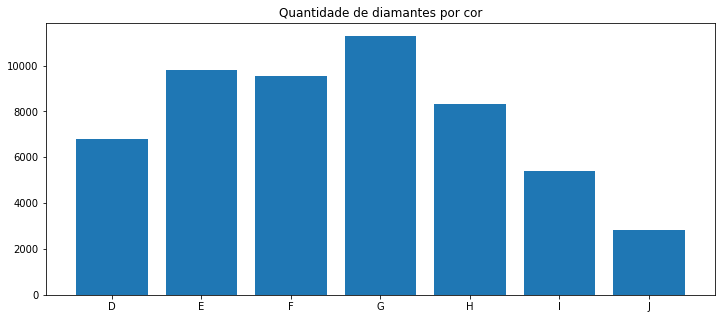

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(['D', 'E', 'F', 'G', 'H', 'I', 'J'], df_diamante.iloc[:,12:19].sum())
plt.title('Quantidade de diamantes por cor')
plt.show()

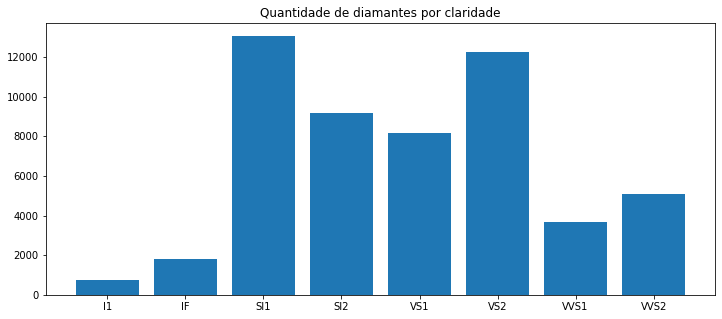

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(['I1','IF','SI1', 'SI2', 'VS1', 'VS2', 'VVS1', 'VVS2'], df_diamante.iloc[:,19:30].sum())
plt.title('Quantidade de diamantes por claridade')
plt.show()

In [ ]:
df_diamante.describe()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_D,color_E,color_F,color_G,color_H,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734,0.029848,0.090953,0.399537,0.255673,0.223990,0.125603,0.181628,0.176900,0.209344,0.153949,0.100519,0.052058,0.013737,0.033185,0.242214,0.170449,0.151483,0.227253,0.067760,0.093919
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699,0.170169,0.287545,0.489808,0.436243,0.416919,0.331404,0.385541,0.381588,0.406844,0.360903,0.300694,0.222146,0.116400,0.179121,0.428427,0.376030,0.358522,0.419061,0.251337,0.291719
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
def separarDados(df_diamante):
  train_ratio = 0.60
  validation_ratio = 0.20
  test_ratio = 0.20

  x_treino, x_teste, y_treino, y_teste = train_test_split(df_diamante.loc[:, df_diamante.columns != 'price'], df_diamante['price'].values, test_size=1 - train_ratio)

  x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_teste, y_teste, test_size=test_ratio/(test_ratio + validation_ratio))

  escala = StandardScaler().fit(x_treino)
  x_treino, x_validacao, x_teste = escala.transform(x_treino), escala.transform(x_validacao), escala.transform(x_teste)

  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [ ]:
def grafico(nome,treino,validacao):
  plt.figure(figsize=(12,5))
  plt.title(nome)

  plt.plot(treino)
  plt.plot(validacao)
  plt.title(f'Função de custo vs Número de Épocas - {nome}')
  plt.xlabel('Épocas')
  plt.ylabel("Função de Custo (J)")
  plt.legend(['Treino', 'Validação'])

  plt.show()

In [ ]:
def executarModelo(modelo,x_treino,x_validacao,y_treino,y_validacao,nome):
  treino_erro,validaca_erro = [],[]
  epocas = 100
  melhor_epoca = None
  melhor_modelo = None
  erro_minimo_validacao = float('inf')

  for epoca in range(epocas):
    modelo.fit(x_treino,y_treino) 

    y_treino_resposta = modelo.predict(x_treino)
    y_validacao_resposta = modelo.predict(x_validacao)

    treino_erro.append(mean_squared_error(y_treino,y_treino_resposta,squared=True))
    validaca_erro.append(mean_squared_error(y_validacao,y_validacao_resposta,squared=True))

    if validaca_erro[-1:][0] < erro_minimo_validacao:
      erro_minimo_validacao = validaca_erro[-1:][0]
      melhor_epoca = epoca + 1
      melhor_modelo = modelo

  print(f"Percentual de acerto do treino com melhor modelo: {round(melhor_modelo.score(x_treino,y_treino)*100,2)}%")
  print(f"Percentual de acerto da validação com melhor modelo: {round(melhor_modelo.score(x_validacao,y_validacao)*100,2)}%")
  print(f"Melhor época: {melhor_epoca}")

  grafico(nome,treino_erro,validaca_erro)

  return melhor_modelo

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = separarDados(df_diamante)

Percentual de acerto do treino com melhor modelo: 91.89%
Percentual de acerto da validação com melhor modelo: 92.09%
Melhor época: 65


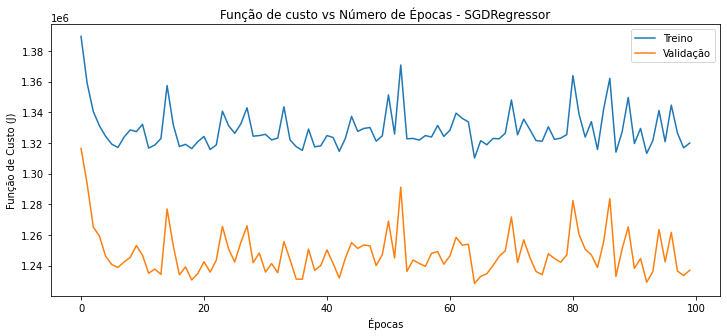

In [ ]:
modelo = executarModelo(SGDRegressor(eta0=0.01,warm_start=True,max_iter=1),x_treino,x_validacao,y_treino,y_validacao,'SGDRegressor')

filename = 'modelo1.sav'
pickle.dump(modelo, open(filename, 'wb'))

Percentual de acerto do treino com melhor modelo: 87.3%
Percentual de acerto da validação com melhor modelo: 87.48%
Melhor época: 52


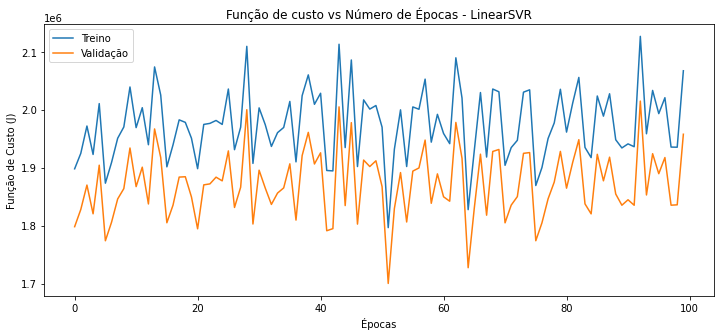

In [ ]:
modelo = executarModelo(LinearSVR(max_iter=1),x_treino,x_validacao,y_treino,y_validacao,'LinearSVR')

filename = 'modelo2.sav'
pickle.dump(modelo, open(filename, 'wb'))

In [ ]:
modelo = RandomForestRegressor()

modelo.fit(x_treino,y_treino) 

print(f"Percentual de acerto do treino: {round(modelo.score(x_treino,y_treino)*100,2)}%")
print(f"Percentual de acerto da validação: {round(modelo.score(x_validacao,y_validacao)*100,2)}%")
  
filename = 'modelo3.sav'
pickle.dump(modelo, open(filename, 'wb'))

Percentual de acerto do treino: 99.73%
Percentual de acerto da validação: 97.87%


In [ ]:
estimators = [('RandomForestRegressor', RandomForestRegressor()),('LinearSVR', LinearSVR(max_iter=1)),('SGDRegressor', SGDRegressor(eta0=0.01,warm_start=True,max_iter=100))]
                                                                  
modelo = StackingRegressor(estimators=estimators)

modelo.fit(x_treino,y_treino) 

print(f"Percentual de acerto do treino: {round(modelo.score(x_treino,y_treino)*100,2)}%")
print(f"Percentual de acerto da validação: {round(modelo.score(x_validacao,y_validacao)*100,2)}%")

filename = 'modelo4.sav'
pickle.dump(modelo, open(filename, 'wb'))

Percentual de acerto do treino: 99.67%
Percentual de acerto da validação: 97.9%


In [ ]:
filename = 'modelo4.sav'
modelo = pickle.load(open(filename, 'rb'))

print(f"Percentual de acerto do teste com StackingRegressor: {round(modelo.score(x_teste,y_teste)*100,2)}%")

Percentual de acerto do teste com StackingRegressor: 98.16%
